# Docking + ML ensemble models

This notebook implements potency prediction using an ensemble of models including Gaussian process regression fitted to molecular fingerprints, as well as linear models relating docking scores to potency. The uncertainty of models/predictions is used to determine their weighting. The method is tested on the Tyk2 dataset from Relay/Google Research (10000 ligands with docking scores and free energies from MD) and on the PDE10A dataset from Roche (pIC50 with docking scores).

In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, QED
from typing import Dict, Tuple, List
from sklearn.linear_model import RidgeCV
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import lsq_linear

### Download Tyk2 dataset

In [9]:
!wget https://raw.githubusercontent.com/google-research/google-research/refs/heads/master/al_for_fep/tyk2_dataset/tyk2_fep.csv

--2026-02-07 19:51:34--  https://raw.githubusercontent.com/google-research/google-research/refs/heads/master/al_for_fep/tyk2_dataset/tyk2_fep.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8003::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 684295 (668K) [text/plain]
Saving to: ‘tyk2_fep.csv’

tyk2_fep.csv        100%[===================>] 668.26K  1.88MB/s    in 0.3s    

2026-02-07 19:51:34 (1.88 MB/s) - ‘tyk2_fep.csv’ saved [684295/684295]



### Download csv with PDE10A splits

In [1]:
!wget https://static-content.springer.com/esm/art%3A10.1007%2Fs10822-022-00478-x/MediaObjects/10822_2022_478_MOESM2_ESM.csv

--2026-02-07 19:32:23--  https://static-content.springer.com/esm/art%3A10.1007%2Fs10822-022-00478-x/MediaObjects/10822_2022_478_MOESM2_ESM.csv
Resolving static-content.springer.com (static-content.springer.com)... 151.101.72.95
Connecting to static-content.springer.com (static-content.springer.com)|151.101.72.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 192150 (188K) [text/csv]
Saving to: ‘10822_2022_478_MOESM2_ESM.csv’

10822_2022_478_MOES 100%[===================>] 187.65K  --.-KB/s    in 0.1s    

2026-02-07 19:32:24 (1.53 MB/s) - ‘10822_2022_478_MOESM2_ESM.csv’ saved [192150/192150]



pde10a_dockingScores.csv contains the docking scores of the poses from the PDE10A dataset rescored with three docking programs (smina, rDock, PLANTS).

We read in datasets and generate fingerprints

In [5]:
def gen_FPs(df: pd.DataFrame, smiles_col: str) -> pd.DataFrame:
    fpgen = AllChem.GetMorganGenerator(radius=4, fpSize=1024, includeChirality=True)
    mols = [Chem.MolFromSmiles(smi) for smi in df[smiles_col]]
    df["fps"] = [fpgen.GetFingerprintAsNumPy(mol) for mol in mols]
    return df

df_pde = gen_FPs(pd.read_csv("pde10a_dockingScores.csv"), "SMILES")
df_pde.head(n=2)

,docking_folder,PLANTS,rDock,smina,SMILES,pic50,fps
0,5sdu_123,-111.750,-85.0819,-10.41106,COc1c(Cl)ccc2nc(CCc3nc(-c4ccccc4)cn3C)[nH]c(=O...,7.480408,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,5sdu_142,-108.957,-71.5014,-9.88228,Cc1oc(-c2ccccc2)nc1CCc1cccc(N2CCCC2)n1,5.696885,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [10]:
df_tyk = gen_FPs(pd.read_csv("tyk2_fep.csv"), "Smiles")
df_tyk.head(n=2)

,LigandId,DockingScore,Smiles,dG,dGError,fps
0,0,-8.654,O=C(Nc1ccnc(NC(=O)C2CCC2)c1)c1c(Cl)cccc1Cl,-2.995,0.455,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,-8.126,O=C(Nc1ccnc(NC(=O)C2CCCC2)c1)c1ccccc1Cl,8.731,0.462,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."


## Score fusion

The BLUE method is implemented to combine scores, while correlations are neglected by default.
Inputs parameters are:
- scores (name of method, mean values): test set scores from each scoring method
- scores_std (name of method, std values): test set standard deviation of each score (from GP, or 0 if docking)
- scores_train: training set scores
- y_train: potency of training set (or free energy)
- eps: tolerance for variance of score residuals to be treated as zero - this only matters for BLUE if neglectResidCorr=True, because the correlation coefficient calculation divides by variance
- neglectResidCorr: if False, do a uncertainty-weighted averaging. If True, compute BLUE estimate according to residual correlations estimated on training set
- positiveSlope: None - no constraint on slope, True - constrain slope to be positive, False - constrain slope to be negative

Returns: combined potency (or free energy) predictions and uncertainties for the test set

In [11]:
def scoreFusion(scores: Dict[str, np.array], scores_std: Dict[str, np.array], scores_train: Dict[str, np.array], \
                        y_train: np.array, eps=1e-6, neglectResidCorr=False, positiveSlope=None) -> Tuple[np.array, np.array]:

    pred_train = {}
    pred = {}
    std = {}

    # fit linear models separately for each series and propagate variance from model + ML
    for series in scores.keys():
    
        x_train = scores_train[series]

        # solve ridge regression system
        X_train = np.vstack([np.ones(len(x_train)), x_train]).T
        if positiveSlope is None:
            bounds = ([-np.inf, -np.inf], [np.inf, np.inf])
        elif positiveSlope[series]:
            bounds = ([-np.inf, 0], [np.inf, np.inf])
        else: 
            bounds = ([-np.inf, -np.inf], [np.inf, 0])
        res = lsq_linear(X_train, y_train, bounds=bounds)
        coef = res.x

        # predict on test set
        pred[series] = coef[0] + coef[1] * scores[series]
 
        # get mse
        y_pred = coef[0] + x_train * coef[1]
        pred_train[series] = y_pred
        mse = mean_squared_error(y_train, y_pred)

        # get variance of residuals for a given series
        var_fit = mse
        var_ml = scores_std[series]**2 * coef[1]**2
        std[series] = np.sqrt(var_fit + var_ml)

    # calculate correlation coefficients of residuals
    series = scores.keys()
    corr = np.zeros((len(series), len(series)))
    for i, iseries in enumerate(series):
        for j, jseries in enumerate(series):
            diff_i = pred_train[iseries] - y_train
            diff_j = pred_train[jseries] - y_train
            if neglectResidCorr or (np.var(diff_i) < eps) or (np.var(diff_j) < eps):
                corr[i,j] = int(i == j)
            else:
                corr[i,j] = pearsonr(diff_i, diff_j).statistic
            corr[j,i] = corr[i,j]

    # combine predictions and variances using the BLUE estimator
    var_matrix =  np.hstack([std[s].reshape(-1, 1) for s in series])
    pred_matrix =  np.hstack([pred[s].reshape(-1, 1) for s in series])
    N = var_matrix.shape[0]
    pred_comb = np.zeros(N)
    var_comb = np.zeros(N)
    weights = np.zeros(len(series)).reshape(1,-1)
    
    for i,v in enumerate(var_matrix):
        C = (v.reshape(-1,1) @ v.reshape(1,-1)) * corr
        C_inv = np.linalg.inv(C)
        U = np.ones((len(v),1)) 
        var_comb[i] = 1 / (U.T @ C_inv @ U).item()
        pred_comb[i] = var_comb[i] * (U.T @ C_inv @ pred_matrix[i].reshape(-1,1)).item()
        weights += var_comb[i] * (U.T @ C_inv)

    weights = weights.flatten() / weights.sum()
    weights = {f"weight_{s}":w for s,w in zip(series, weights)}

    return pred_comb, np.sqrt(var_comb), weights

## GP model with Tanimoto kernel

We use a GPyTorch implementation of GP which can run on the GPU.

In [12]:
import torch
import gpytorch
from gpytorch.kernels import Kernel, ScaleKernel, RBFKernel
from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood


class TanimotoKernel(Kernel):

    is_stationary = False
    has_lengthscale = False

    def __init__(self, **kwargs):
        Kernel.__init__(self, **kwargs)

    def forward(self, x1, x2, diag=False, **params):
        if diag:
            assert x1.size() == x2.size() and torch.equal(x1, x2)
            return torch.ones(*x1.shape[:-2], x1.shape[-2], dtype=x1.dtype, device=x1.device)
        else:
            return self.covar_dist(x1, x2, **params)

    def batch_tanimoto_sim(self, x1: torch.Tensor, x2: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:

        if x1.ndim < 2 or x2.ndim < 2:
            raise ValueError("Tensors must have a batch dimension")
    
        dot_prod = torch.matmul(x1, torch.transpose(x2, -1, -2))
        x1_norm = torch.sum(x1**2, dim=-1, keepdims=True)
        x2_norm = torch.sum(x2**2, dim=-1, keepdims=True)
        tan_similarity = (dot_prod + eps) / (eps + x1_norm + torch.transpose(x2_norm, -1, -2) - dot_prod)
        return tan_similarity.clamp_min_(0)  # zero out negative values for numerical stability
    
    def covar_dist(self, x1, x2, last_dim_is_batch=False, **params):
        if last_dim_is_batch:
            x1 = x1.transpose(-1, -2).unsqueeze(-1)
            x2 = x2.transpose(-1, -2).unsqueeze(-1)

        return self.batch_tanimoto_sim(x1, x2)


class ExactGPModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        ExactGP.__init__(self, train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = TanimotoKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class GaussianProcess:
    def __init__(self):
        self.model = None
        self.likelihood = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        torch.cuda.empty_cache()

    def fit(self, X, y):

        X = torch.tensor(X).to(torch.float).to(self.device)
        y = torch.tensor(y).to(torch.float).to(self.device)

        # normalize y
        self.mean_y = torch.mean(y).to(self.device)
        self.std_y = torch.std(y, unbiased=False).to(self.device)
        y_norm = (y - self.mean_y) / self.std_y

        self.likelihood = GaussianLikelihood().to(self.device)
        self.likelihood.initialize(noise=1e-4)
        
        self.model = ExactGPModel(X, y_norm, self.likelihood).to(self.device)
        self.model.train()
        self.likelihood.train()
        optimizer = torch.optim.LBFGS([{'params': self.model.parameters()}], lr=0.1, max_iter=100)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood, self.model)

        def closure():
            optimizer.zero_grad()
            output = self.model(X)
            loss = -mll(output, y_norm)
            loss.backward()
            return loss

        for i in range(100):
            loss = optimizer.step(closure)

        #return self

    def predict(self, X, return_std=False):
        X = torch.tensor(X).to(self.device)

        with torch.no_grad():
            self.model.eval()
            predictions = self.model(X)
        mean = (predictions.loc * self.std_y + self.mean_y).cpu().detach().numpy()

        if return_std:
            std = np.sqrt((predictions.variance * self.std_y**2).cpu().detach().numpy())
            return mean, std
        else:
            return mean

/home/beta/miniforge3/envs/al/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helper functions for training and inference (based on docking and/or GP)

In [14]:
from scipy.stats import linregress

# get docking method with best Spearman correlation on the training set
def findBestPredictor(df: pd.DataFrame, trainVars: List[str], targetVar: str) -> Tuple[str, Dict]:
    rho = {}
    for var in trainVars:
        rho[var] = spearmanr(df[targetVar], -df[var])[0]
    best_rho = max(rho, key=lambda k: rho[k])
    return best_rho, rho

# train GP model and do score fusion
def fitPredict(df: pd.DataFrame, trainIndex: List[int], trainVars: List[str], targetVar: str, \
               trainGP: bool = True, neglectResidCorr = False, positiveSlope=True) -> None:

    train = df.loc[trainIndex]

    if trainGP:
        gp = GaussianProcess()
        gp.fit(train["fps"].tolist(), train[targetVar].tolist())
        pred_gp, std_gp = gp.predict(df["fps"].tolist(), return_std=True)
        pred = {targetVar: pred_gp} | {k: df[k].to_numpy() for k in trainVars}
        std = {targetVar: std_gp} | {k: np.repeat(0, df.shape[0]) for k in trainVars}
    else:
        pred = {k: df[k].to_numpy() for k in trainVars}
        std = {k: np.repeat(0, df.shape[0]) for k in trainVars}

    scores_train = {k: train[k].to_numpy() for k in pred.keys()}
    y_train = train[targetVar].to_numpy()

    if positiveSlope is not None:
        positiveSlope = {k:(True if k == targetVar else positiveSlope) for k in pred.keys()}
    
    df["pred"], df["std"], weights = scoreFusion(pred, std, scores_train, y_train, neglectResidCorr=neglectResidCorr, positiveSlope=positiveSlope)
    return weights

Helper functions for performance analysis

In [18]:
import math

def calcCumulativeRecall(df, trainIndex: pd.Index, recall_frac: List[int], targetVar: str, maximizeTarget: bool):
    recall = {}
    for percentage in recall_frac:
        frac = float(percentage) * 0.01
        cutoff = math.ceil(df.shape[0]*frac)
        topdf = df.sort_values(by=targetVar, ascending=(not maximizeTarget))[:cutoff]
        recall_f = len(topdf.index.intersection(trainIndex)) / cutoff
        recall = recall | {f"Top {percentage}% Recall": recall_f}
    return recall

def evaluate(df: pd.DataFrame, trainIndex: List[int], targetVar: str):
    test = df.loc[~df.index.isin(trainIndex)]
    true = test[targetVar].to_numpy()
    pred = test.pred.to_numpy()

    pearson = pearsonr(true, pred).statistic
    spearman = spearmanr(true, pred)[0]
    r2 = r2_score(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return {"pearson": pearson, "spearman": spearman, "r2": r2, "rmse": rmse}

## 1. Random train-test splits with variable training set sizes

Inputs:
- data: dataset to run experiments with (tyk2, or pde10a)
- trainVars: name(s) of column(s) in data containing docking scores to be fitted
- targetVar: column name containing potency (pIC50) or free energies
- train_sizes: do train/test split for each training set size defined in this list
- findBest: if True, only used one set of docking scores and select the one with the best Spearman correlation on the training set
- n_repeats: number of repeats for each train size (used as random seed for the training set selection)
- maximizeTarget: used to set constraint on slope of linear models. Should be True for pIC50 and False for dG.
- neglectResidCorr: use uncertainty-based weighting (True) or BLUE incl. accounting for residual correlations (False)

In [15]:
from tqdm import tqdm

def runTrainTestExperiment(data: pd.DataFrame, trainVars: List[int], targetVar: str, train_sizes: List[int], \
                           findBest=False, n_repeats=10, maximizeTarget=True, neglectResidCorr=False):
    metrics = pd.DataFrame()
    for s in tqdm(train_sizes):
        for r in range(n_repeats):
            df = data.copy()
            row = {"train_size": s, "repeat": r}
            trainIndex = df.sample(s, random_state=r).index
            if findBest:
                best, rho = findBestPredictor(df.loc[trainIndex], trainVars, targetVar)
                predictors = [best]
            else:
                predictors = trainVars
                best = None
            fitPredict(df, trainIndex, predictors, targetVar, neglectResidCorr=neglectResidCorr, positiveSlope=(not maximizeTarget))
            metrics_row = evaluate(df, trainIndex, targetVar)
            recall = {}
            for recall_percentage in [1,2,5]:
                frac = float(recall_percentage) * 0.01
                cutoff = math.ceil(df.shape[0]*frac)
                pred_top_n_index = df.sort_values(by="pred", ascending=(not maximizeTarget))[:cutoff].index
                recall = recall | calcCumulativeRecall(df, pred_top_n_index, [recall_percentage], targetVar, maximizeTarget)
            metrics = pd.concat([metrics, pd.DataFrame(row | metrics_row | recall | {"best_predictor": best}, index=[0])])
    return metrics

In [17]:
import warnings
warnings.filterwarnings("ignore")

In [159]:
res_tyk_dock = runTrainTestExperiment(df_tyk, ["DockingScore"], "dG", [10] + list(range(20, 620, 20)), maximizeTarget=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [05:47<00:00, 11.20s/it]


In [160]:
res_tyk_gp = runTrainTestExperiment(df_tyk, [], "dG", [10] + list(range(20, 620, 20)), maximizeTarget=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [05:49<00:00, 11.26s/it]


In [161]:
res_pde_all = runTrainTestExperiment(df_pde, ["smina", "PLANTS", "rDock"], "pic50", [10] + list(range(20, 620, 20)))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [03:30<00:00,  6.79s/it]


In [165]:
res_pde_all_indep = runTrainTestExperiment(df_pde, ["smina", "PLANTS", "rDock"], "pic50", [10] + list(range(20, 620, 20)), neglectResidCorr=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [03:32<00:00,  6.84s/it]


In [20]:
res_pde_best = runTrainTestExperiment(df_pde, ["smina", "PLANTS", "rDock"], "pic50", [10] + list(range(20, 620, 20)), findBest=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [03:29<00:00,  6.76s/it]


In [19]:
res_pde_gp = runTrainTestExperiment(df_pde, [], "pic50", [10] + list(range(20, 620, 20)))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [03:29<00:00,  6.77s/it]


In [ ]:
res_pde_best_copy = res_pde_best.copy()
res_pde_all_copy = res_pde_all.copy()
res_pde_indep_copy = res_pde_all_indep.copy()
res_pde_gp_copy = res_pde_gp.copy()
res_pde_gp_copy["method"] = "GP only"
res_pde_best_copy["method"] = "GP+best docking method"
res_pde_all_copy["method"] = "GP+all docking methods (corr.)"
res_pde_indep_copy["method"] = "GP+all docking methods (indep.)"
res_pde = pd.concat([res_pde_best_copy, res_pde_all_copy, res_pde_indep_copy, res_pde_gp_copy])

In [162]:
res_tyk_gp_copy = res_tyk_gp.copy()
res_tyk_dock_copy = res_tyk_dock.copy()

res_tyk_gp_copy["method"] = "GP only"
res_tyk_dock_copy["method"] = "docking+GP"
res_tyk = pd.concat([res_tyk_dock_copy, res_tyk_gp_copy])

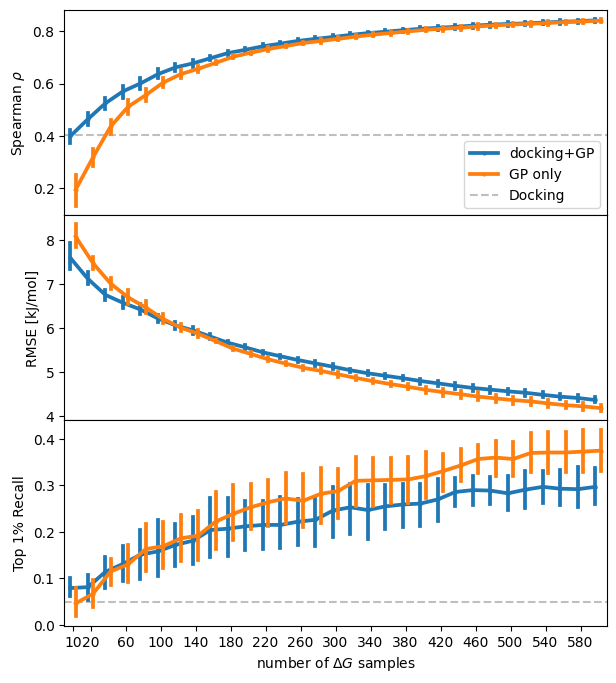

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

PERCENTAGE = 1
fig, ax = plt.subplots(3, 1, figsize=(7,8), sharex=True)

for i,series in enumerate(["spearman", "rmse", f"Top {PERCENTAGE}% Recall"]):
    sns.pointplot(res_tyk, x="train_size", y=series, hue="method", dodge=0.3, ax=ax[i], legend=(i==0), palette="tab10", markersize=1)

spearman_tyk = spearmanr(df_tyk.dG, df_tyk.DockingScore)[0]
ax[0].axhline(spearman_tyk, label="Docking", ls="--", color="gray", zorder=1, alpha=0.5)

frac = float(PERCENTAGE) * 0.01
cutoff = math.ceil(df_tyk.shape[0]*frac)
pred_top_n_index = df_tyk.sort_values(by="DockingScore")[:cutoff].index
recall = calcCumulativeRecall(df_tyk, pred_top_n_index, [PERCENTAGE], "dG", False)
ax[2].axhline(recall[f"Top {PERCENTAGE}% Recall"], label="Docking", ls="--", color="gray", zorder=1, alpha=0.5)

handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles=handles, labels=labels)

ax[2].set_xlabel(r'number of $\Delta G$ samples')
ax[0].set_ylabel(r'Spearman $\rho$')
ax[1].set_ylabel(r'RMSE [kJ/mol]')

for i in range(3):
    ax[i].set_xticks([0] + list(range(1, 30, 2)))

plt.subplots_adjust(hspace=0)
#fig.savefig("figs/train_tyk2.svg", bbox_inches="tight")

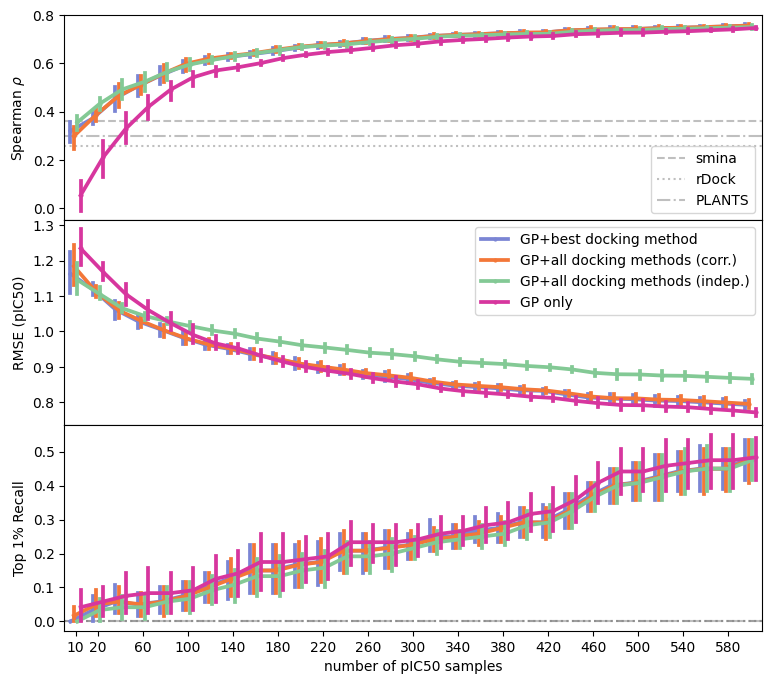

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

CB_color_cycle = ['#7b85d4', '#f37738', '#83c995', '#d7369e']
PERCENTAGE = 1
fig, ax = plt.subplots(3, 1, figsize=(9,8), sharex=True)

# res_pde_plot = res_pde[~res_pde.method.str.endswith("(corr.)")]
# res_pde_plot.loc[res_pde_plot.method.str.endswith("(indep.)"), "method"] = "GP+all docking methods"

for i,series in enumerate(["spearman", "rmse", f"Top {PERCENTAGE}% Recall"]):
    sns.pointplot(res_pde, x="train_size", y=series, hue="method", dodge=0.45, ax=ax[i], legend=(i==1), palette=CB_color_cycle, markersize=1)

spearman = {}
ls = iter(["--", ":", "-."])
for var in ["smina", "rDock", "PLANTS"]:
    spearman[var] = spearmanr(df_pde.pic50, -df_pde[var])[0]
    ax[0].axhline(spearman[var], label=var, ls=next(ls), color="gray", zorder=1, alpha=0.5)

frac = float(PERCENTAGE) * 0.01
cutoff = math.ceil(df_pde.shape[0]*frac)

ls = iter(["--", ":", "-."])
for var in ["smina", "rDock", "PLANTS"]:
    pred_top_n_index = df_pde.sort_values(by=var, ascending=False)[:cutoff].index
    recall = calcCumulativeRecall(df_pde, pred_top_n_index, [PERCENTAGE], "pic50", True)
    ax[2].axhline(recall[f"Top {PERCENTAGE}% Recall"], label="Docking", ls=next(ls), color="gray", zorder=1, alpha=0.5)

handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles=handles, labels=labels)

ax[2].set_xlabel("number of pIC50 samples")
ax[0].set_ylabel(r'Spearman $\rho$')
ax[1].set_ylabel(r'RMSE (pIC50)')

for i in range(3):
    ax[i].set_xticks([0] + list(range(1, 30, 2)))

plt.subplots_adjust(hspace=0)
ax[1].legend(title="")

fig.savefig("figs/train_pde_corr.pdf", bbox_inches="tight")

## 2. Random, temporal and scaffold splits on PDE10A

The runSplits function is similar to the random train-test setup, except that no repeats are possible for predefined splits, and therefore errors are instead estimated using bootstrapping on the test set. For docking methods we also evaluate correlation and RMSE on the training set.

In [26]:
df_roche = pd.read_csv("10822_2022_478_MOESM2_ESM.csv", index_col="compound_id")
columnsToKeep = [col for col in df_roche.columns if col.endswith("split")]
df_roche = df_roche[columnsToKeep + ["docking_folder"]]
df_pde_splits = df_pde.merge(df_roche, on="docking_folder")

In [27]:
from scipy.stats import bootstrap

def pearson(true, pred):
    return pearsonr(true, pred).statistic

# get error from bootstrapping (2 sigma ~ 95% CI)
def bootstrapMetrics(df, targetVar):
    true = df[targetVar].to_numpy()
    pred = df.pred.to_numpy()

    callableDict = { 
        "pearson": lambda true, pred: pearsonr(true, pred).statistic, 
        "spearman": lambda true, pred: spearmanr(true, pred)[0],
        "r2": lambda true, pred: r2_score(true, pred),
        "rmse": lambda true, pred: np.sqrt(mean_squared_error(true, pred))
    }

    resDict = {}
    for metric, func in callableDict.items():
        res = bootstrap((true, pred), statistic=func, n_resamples=1000, method="percentile")
        mean = func(true, pred)
        std = 2*res.standard_error
        resDict = resDict | {metric: mean, f"{metric}_std": std}
    
    return resDict

def runSplits(data: pd.DataFrame, trainVars: List[int], targetVar: str, splits: List[str], name: str, \
                      trainGP=True, evalTrain=False, neglectResidCorr=False):
    metrics = pd.DataFrame()
    for s in splits:
        df = data.copy().dropna(subset=s)
        df = df[(df[s] != "val")]
        row = {"split": s, "name": name}
        trainIndex = df[df[s] == "train"].index
        weights = fitPredict(df, trainIndex, trainVars, targetVar, trainGP, neglectResidCorr=neglectResidCorr, positiveSlope=False)
        train = df.loc[trainIndex]
        test = df.loc[~df.index.isin(trainIndex)]
        if evalTrain:
            metrics_row = bootstrapMetrics(train, targetVar)
        else:
            metrics_row = bootstrapMetrics(test, targetVar)
        metrics = pd.concat([metrics, pd.DataFrame(row | metrics_row | weights, index=[0])])
    return metrics

In [28]:
res = runSplits(df_pde_splits, [], "pic50", columnsToKeep, "GP only")

estimators = ["smina", "PLANTS", "rDock"]
for estimator in estimators:
    res_train = runSplits(df_pde_splits, [estimator], "pic50", columnsToKeep, f"{estimator} (train)", trainGP=False, evalTrain=True)
    res_test = runSplits(df_pde_splits, [estimator], "pic50", columnsToKeep, f"{estimator}", trainGP=False)
    res_gp = runSplits(df_pde_splits, [estimator], "pic50", columnsToKeep, f"{estimator}+GP")
    res = pd.concat([res, res_train, res_test, res_gp])

# consensus
for corr in ["corr", "indep"]:
    neglectResidCorr = (corr == "indep")
    res_train = runSplits(df_pde_splits, estimators, "pic50", columnsToKeep, f"all dock (train, {corr}.)", trainGP=False, \
                                  evalTrain=True, neglectResidCorr=neglectResidCorr)
    res_test = runSplits(df_pde_splits, estimators, "pic50", columnsToKeep, f"all dock ({corr}.)", trainGP=False, \
                                neglectResidCorr=neglectResidCorr)
    res_gp = runSplits(df_pde_splits, estimators, "pic50", columnsToKeep, f"all dock+GP ({corr}.)", \
                              neglectResidCorr=neglectResidCorr)
    res = pd.concat([res, res_train, res_test, res_gp])

### Plot results

In [29]:
import seaborn as sns
import re

# some weights are negative - find scales relative to their absolute values
def scaleWeights(row, variable):
    weights = [row.weight_pic50, row.weight_smina, row.weight_rDock, row.weight_PLANTS]
    weights_norm = sum([np.abs(w) for w in weights])
    new_norm = row[variable]
    weights = [np.abs(w)/weights_norm*new_norm for w in weights]
    assert(np.abs(sum(weights) - new_norm) < 1e-6)
    return weights


def makePlot(res, SPLIT, mode = "paper", legend=True, xaxis=True, title=True): # mode can be paper or SI
    variable = "spearman" # we draw bars based on Spearman rho

    res_plot = res.copy().fillna(0).reset_index(drop=True) # not all compounds are assign to train/validation/test
    res_plot[["weight_pic50", "weight_smina", "weight_rDock", "weight_PLANTS"]] = \
        res_plot.apply(lambda row: scaleWeights(row, variable), axis=1, result_type="expand")
    
    res_split = res_plot[res_plot.split == SPLIT]
    renamer = { "weight_pic50": "pic50", "weight_smina": "smina", "weight_rDock": "rDock", "weight_PLANTS": "PLANTS"}
    res_split = res_split.rename(columns=renamer) # set more readable names for weight fractions

    if mode == "paper": # plot independent docking combinations, GP and standalone docking
        series_to_drop = ["smina+GP", "rDock+GP", "PLANTS+GP", "all dock (train, corr.)", "all dock (corr.)", "all dock+GP (corr.)"]
        res_split = res_split[~res_split["name"].isin(series_to_drop)]
        res_split["name"] = res_split.name.apply(lambda name: re.sub(" \(indep.\)|, indep.", "", name))
    else: # plot independent vs correlated docking combinations
        res_split = res_split[res_split["name"].str.startswith("all")]

    # sort series to make sure that highest Spearman comes on the top for train + test
    res_split["train"] = res_split.name.str.contains("train")
    res_split.sort_values(by=["train", variable], ascending=[False, True], inplace=True)
    err = res_split.copy()
    res_split = res_split[["name"] + list(renamer.values())].set_index("name")
    
    # insert empty row
    insert_iloc = len([name for name in res_split.index.unique() if "train" in name]) #nr of train series (for drawing the solid line)
    df_before = res_split.iloc[:insert_iloc]
    df_after = res_split.iloc[insert_iloc:]  
    res_split = pd.concat([df_before, pd.DataFrame([{}],index=[""]), df_after], ignore_index=False)
    
    sns.set_palette("terrain")
    figsize = (7.5,2.7) if mode == "paper" else (7.5, 1.7)
    fig, axs = plt.subplots(1, 2, sharey=True, width_ratios=[5,1], figsize=figsize)
    
    res_split.plot.barh(stacked=True, ax=axs[0], legend=legend)
    ax = axs[0]
    plt.subplots_adjust(wspace=0)
    axs[1].set_xticks([])
    
    ax.set_ylabel("")
    if variable == "spearman":
        ax.set_xlabel(r'Spearman $\rho$')
        ax.set_xlim([0,1])

    if not xaxis:
        ax.set_xlabel("")
        ax.set_xticks([])

    # draw horizontal line between train + test sets
    ax.axhline(y=insert_iloc, color="k")
    yaxis = np.arange(res_split.shape[0])
    spearman = err[variable].tolist()
    spearman.insert(insert_iloc, 0)
    xerr = err[f"{variable}_std"].tolist()
    xerr.insert(insert_iloc, 0)
    
    ax.errorbar(spearman, yaxis, xerr=xerr, fmt="o", markersize=0, ecolor="lightsteelblue", capsize=4)

    # write spearman and rmse values next to bar & in side column
    bold_labels = ["all dock", "all dock+GP"]
    for label in ax.get_yticklabels():
        y = label.get_position()[1]
        x = min(spearman[y] + xerr[y] + 0.02, 0.8)
        if label.get_text() in bold_labels:
            label.set_fontweight('bold')
            ax.text(x, y-0.2, f"{spearman[y]:.2f} " + r'$\pm$' + f" {xerr[y]:.2f}", fontweight='bold', color="dimgrey")
        elif label.get_text() != "":
            ax.text(x, y-0.2, f"{spearman[y]:.2f} " + r'$\pm$' + f" {xerr[y]:.2f}", color="dimgrey")

        if label.get_text() != "":
            rmse = err.rmse.tolist()
            rmse.insert(insert_iloc, 0)
            xerr_rmse = err["rmse_std"].tolist()
            xerr_rmse.insert(insert_iloc, 0)
            if y-1 == np.argmin(err.rmse[insert_iloc:])+insert_iloc:
                axs[1].text(0.05, y-0.2, f"{rmse[y]:.2f} " + r'$\pm$' + f" {xerr_rmse[y]:.2f}", color="dimgrey", fontweight='bold')
            else:
                axs[1].text(0.1, y-0.2, f"{rmse[y]:.2f} " + r'$\pm$' + f" {xerr_rmse[y]:.2f}", color="dimgrey")

    ax.set_title(SPLIT)
    if title:
        axs[1].set_title("RMSE")

    fig.savefig(f"figs/{SPLIT}_{mode}.svg", bbox_inches="tight")

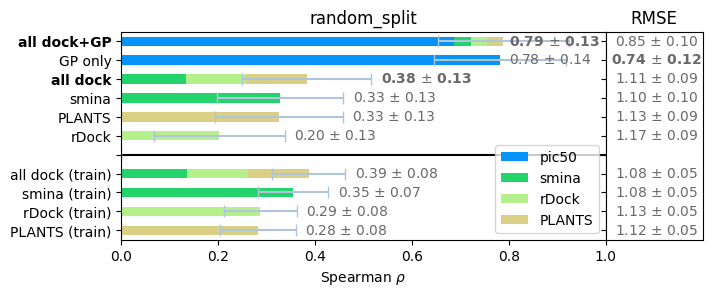

In [30]:
makePlot(res, "random_split")

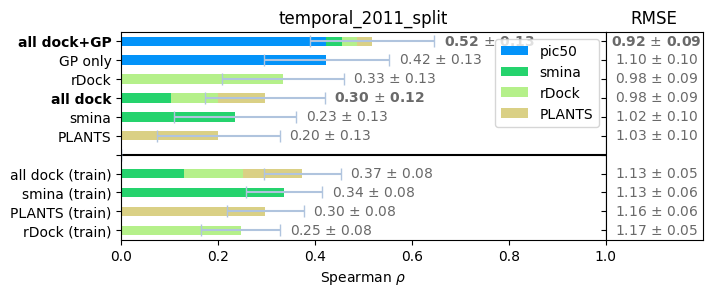

In [31]:
makePlot(res, "temporal_2011_split")

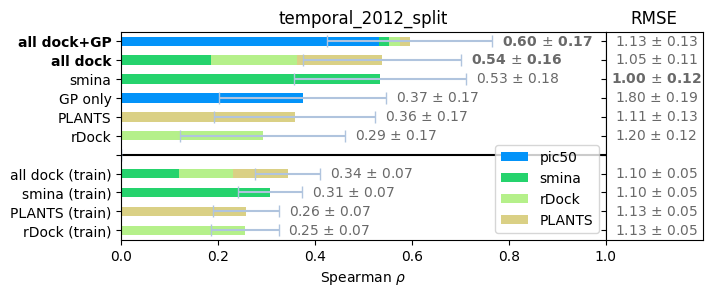

In [32]:
makePlot(res, "temporal_2012_split")

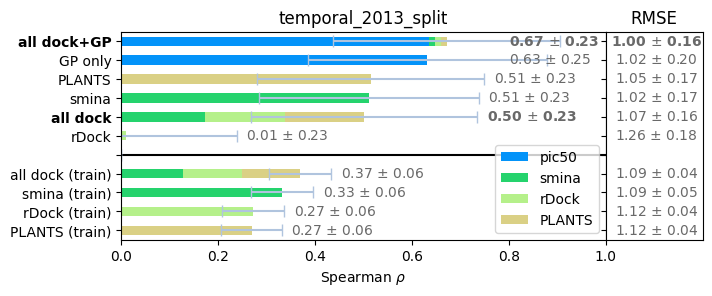

In [33]:
makePlot(res, "temporal_2013_split")

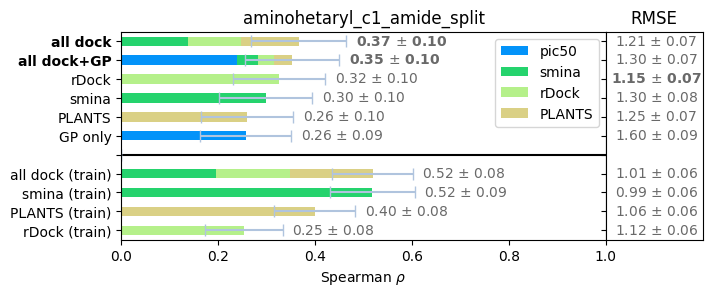

In [34]:
makePlot(res, "aminohetaryl_c1_amide_split")

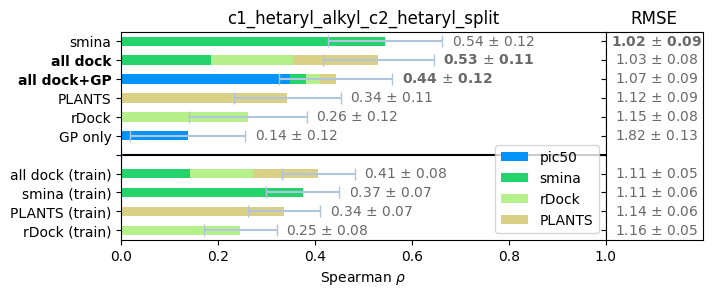

In [35]:
makePlot(res, "c1_hetaryl_alkyl_c2_hetaryl_split")

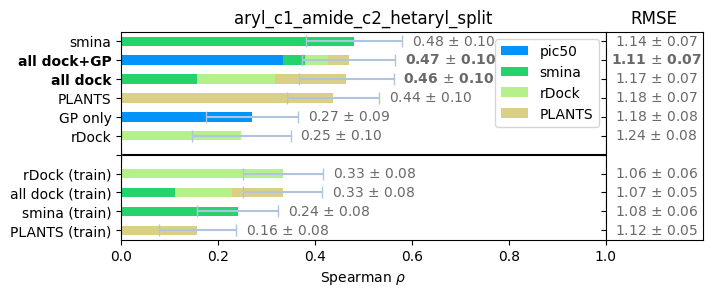

In [36]:
makePlot(res, "aryl_c1_amide_c2_hetaryl_split")

## 3. Active Learning

We run 10 cycles for Tyk2 and 5 for PDE10A (because this dataset is smaller).
Input parameters:
- data: tyk2 or pde10a datasest
- trainVars: column names of docking scores to use
- targetVar: column name of potency or dG column
- totalCompounds: number of ligands to acquire in total (we use 300 for pde10a and 600 for tyk2)
- n_repeats: number of repeats of each AL run with different random selection of the initial batch
- batch_size: number of compounds acquired per cycle (excl initial batch)
- initial_batch_size: number of compounds chosen at random in the beginning (everything else chosen based on potency)
- recall_frac: top n% recall to track
- maximizeTarget: used to set constraint on docking slope

In [10]:
from tqdm import tqdm

def runALExperiment(data: pd.DataFrame, trainVars: List[int], targetVar: str, totalCompounds: int, \
                           n_repeats=10, batch_size=20, initial_batch_size=20, recall_frac=[1,2,5], maximizeTarget=True):
    
    metrics = pd.DataFrame()
    indices = [0]*data.shape[0]

    # run multiple repeats with different random initializations
    for r in range(n_repeats):
        df = data.copy()
        trainIndex = df.sample(initial_batch_size, random_state=r).index

        # AL loop
        while len(trainIndex) <= totalCompounds:
            acquired = len(trainIndex)
            row = {"repeat": r, "acquired": acquired}
            recall = calcCumulativeRecall(df, trainIndex, recall_frac, targetVar, maximizeTarget)
            fitPredict(df, trainIndex, trainVars, targetVar, neglectResidCorr=True, positiveSlope=(not maximizeTarget))
            # greedy selection
            if (acquired == initial_batch_size) and (initial_batch_size < batch_size):
                actualBatchSize = batch_size - initial_batch_size
            else:
                actualBatchSize = batch_size
            next_batch = df[~df.index.isin(trainIndex)].sort_values(by="pred", ascending=(not maximizeTarget))[:actualBatchSize]
            trainIndex = trainIndex.union(next_batch.index)
            # calculate model metrics and recall
            metrics_row = evaluate(df, trainIndex, targetVar)
            metrics = pd.concat([metrics, pd.DataFrame(row | metrics_row | recall, index=[0])])

        indices = [e+1 if i in trainIndex else e for i,e in enumerate(indices)]
            
    return metrics, indices

In [12]:
estimators = ["smina", "PLANTS", "rDock"]
index_pde = {}

kwargs = {"maximizeTarget": True, "totalCompounds": 300, "batch_size": 60, "n_repeats": 10}

metrics_20_all, index_pde["20_all"] = runALExperiment(df_pde, estimators, "pic50", initial_batch_size=20, **kwargs)
metrics_20_all["series"] = "20 warmup samples, all docking"

metrics_20_gp, index_pde["20_gp"] = runALExperiment(df_pde, [], "pic50", initial_batch_size=20, **kwargs)
metrics_20_gp["series"] = "20 warmup samples, GP only"

metrics_40_all, index_pde["40_all"] = runALExperiment(df_pde, estimators, "pic50", initial_batch_size=40, **kwargs)
metrics_40_all["series"] = "40 warmup samples, all docking"

metrics_40_gp, index_pde["40_gp"] = runALExperiment(df_pde, [], "pic50", initial_batch_size=40, **kwargs)
metrics_40_gp["series"] = "40 warmup samples, GP only"

metrics_60_all, index_pde["60_all"] = runALExperiment(df_pde, estimators, "pic50", initial_batch_size=60, **kwargs)
metrics_60_all["series"] = "60 warmup samples, all docking"

metrics_60_gp, index_pde["60_gp"] = runALExperiment(df_pde, [], "pic50", initial_batch_size=60, **kwargs)
metrics_60_gp["series"] = "60 warmup samples, GP only"

In [13]:
metrics_pde = pd.concat([metrics_60_all, metrics_60_gp, metrics_40_all, metrics_40_gp, metrics_20_all, metrics_20_gp])

In [28]:
estimators = ["DockingScore"]
index_tyk = {}

kwargs = {"maximizeTarget": False, "totalCompounds": 600, "batch_size": 60, "n_repeats": 10}

# 60 warmup samples
metrics_60_all, index_tyk["60_all"] = runALExperiment(df_tyk, estimators, "dG", initial_batch_size=60, **kwargs)
metrics_60_all["series"] = "60 warmup samples, docking+GP"

metrics_60_gp, index_tyk["60_gp"] = runALExperiment(df_tyk, [], "dG", initial_batch_size=60, **kwargs)
metrics_60_gp["series"] = "60 warmup samples, GP only"

# 20 warmup samples
metrics_20_all, index_tyk["20_all"] = runALExperiment(df_tyk, estimators, "dG", initial_batch_size=20, **kwargs)
metrics_20_all["series"] = "20 warmup samples, docking+GP"

metrics_20_gp, index_tyk["20_gp"] = runALExperiment(df_tyk, [], "dG", initial_batch_size=20, **kwargs)
metrics_20_gp["series"] = "20 warmup samples, GP only"

# 40 warmup samples
metrics_40_all, index_tyk["40_all"] = runALExperiment(df_tyk, estimators, "dG", initial_batch_size=40, **kwargs)
metrics_40_all["series"] = "40 warmup samples, docking+GP"

metrics_40_gp, index_tyk["40_gp"] = runALExperiment(df_tyk, [], "dG", initial_batch_size=40, **kwargs)
metrics_40_gp["series"] = "40 warmup samples, GP only"

In [65]:
metrics_tyk = pd.concat([metrics_60_all, metrics_60_gp, metrics_40_all, metrics_40_gp, metrics_20_all, metrics_20_gp])

### make plots

In [19]:
# Seaborn pointplot has a bug which make it sometimes not connect points with lines - here is a dirty workaround to add the missing line segments
def fixMissingLineSegment(ax, dodge, df, y):
    series = ["20 warmup samples, docking+GP", "20 warmup samples, GP only"]
    colors = [plt.cm.tab20(4), plt.cm.tab20(5)]
    
    for i in range(2):
        sub = df[df.series == series[i]]
        y0 = sub[sub.acquired == 20][y].mean()
        y1 = sub[sub.acquired == 60][y].mean()
        ax.plot([20+4*(1.5+0.5*i)*dodge, 60+4*(1.5+0.5*i)*dodge], [y0, y1], color=colors[i], zorder=i+4, linewidth=2.5)

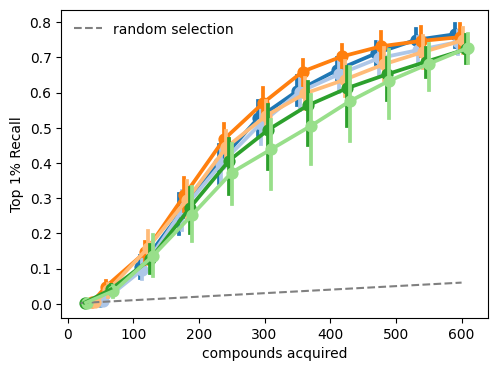

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5,4))
order = metrics_tyk.series.unique()[::-1]
pp = sns.pointplot(metrics_tyk, x="acquired", y="Top 1% Recall", hue="series", dodge=1, palette="tab20", ax=ax, native_scale=True, legend=False)

ax.plot([20, 600], np.array([20, 600])/df_tyk.shape[0], color="gray", ls="--", label="random selection")
ax.set_xlabel("compounds acquired")
ax.legend(loc="best", frameon=False)

handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles=handles, labels=labels, frameon=False, title=None)
fixMissingLineSegment(ax, 1, metrics_tyk, "Top 1% Recall")
fig.savefig("figs/al-tyk2-recall.svg", bbox_inches="tight")

plt.show()

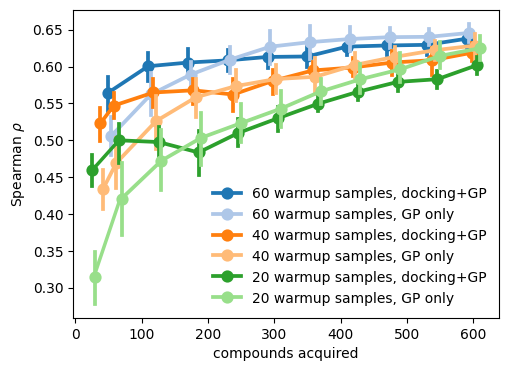

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5,4))
sns.pointplot(metrics_tyk, x="acquired", y="spearman", hue="series", dodge=1, palette="tab20", ax=ax, native_scale=True)

ax.set_ylabel(r'Spearman $\rho$')
ax.set_xlabel("compounds acquired")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, frameon=False, title=None)
fixMissingLineSegment(ax, 1, metrics_tyk, "spearman")
fig.savefig("figs/al-tyk2-spearman.svg", bbox_inches="tight")

plt.show()

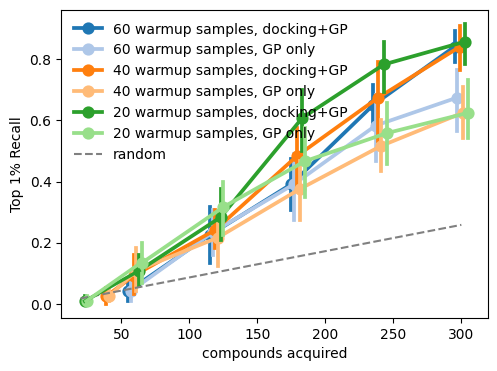

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

fig, ax = plt.subplots(figsize=(5.5,4))
metrics_pde["series"] = metrics_pde.series.apply(lambda name: re.sub("all docking", "docking+GP", name))

sns.pointplot(metrics_pde, x="acquired", y="Top 1% Recall", hue="series", dodge=0.5, palette="tab20", ax=ax, native_scale=True, legend=True)


ax.plot([20, 300], np.array([20, 300])/df_pde.shape[0], color="gray", ls="--", label="random")
ax.set_xlabel("compounds acquired")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, frameon=False, title=None)

fixMissingLineSegment(ax, 0.5, metrics_pde, "Top 1% Recall")
fig.savefig("figs/al-pde-recall.svg", bbox_inches="tight")

plt.show()

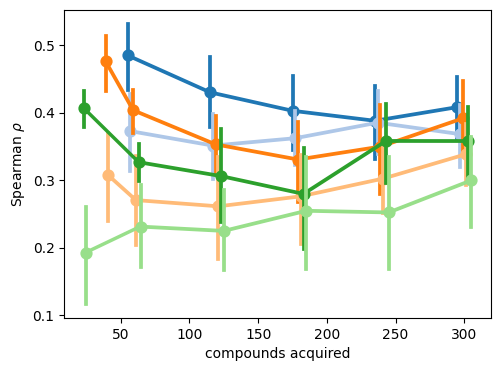

In [18]:
fig, ax = plt.subplots(figsize=(5.5,4))
sns.pointplot(metrics_pde, x="acquired", y="spearman", hue="series", dodge=0.5, palette="tab20", ax=ax, native_scale=True, legend=False)
ax.set_xlabel("compounds acquired")
ax.set_ylabel(r'Spearman $\rho$')

fixMissingLineSegment(ax, 0.5, metrics_pde, "spearman")
fig.savefig("figs/al-pde-spearman.svg", bbox_inches="tight")
plt.show()

### UMAPs

In [90]:
import umap
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

reducer = umap.UMAP(n_neighbors=50, random_state=0)
embedding_tyk = reducer.fit_transform(df_tyk.fps.tolist())
embedding_pde = reducer.fit_transform(df_pde.fps.tolist())

In [188]:
import matplotlib.colors as mcolors

def umap_plot(hue_index, cbar_label, embedding, cbar=True, size=12, title=None, reverse=False, normalize=False):
    order = np.argsort(hue_index)
    if reverse:
        order = order[::-1]
    ax = plt.subplot()
    ax.set_facecolor("lightgray")
    if normalize:
        norm = mcolors.Normalize(vmin=0, vmax=10)
    else:
        norm=None
    
    plt.scatter(
        embedding[order, 0],
        embedding[order, 1],
        c=[hue_index[i] for i in order],
        cmap="Reds" if not reverse else "Reds_r",
        s=size/2,
        norm=norm,
    )

    if cbar:
        cbar = plt.colorbar()
        cbar.ax.tick_params(labelsize=size)
        cbar.set_label(cbar_label, size=size)
    
    plt.xticks([])
    plt.yticks([])
    # plt.xlabel("UMAP 1", size=size)
    # plt.ylabel("UMAP 2", size=size)
    plt.title(title, size=size)

In [415]:
df_pde_splits.columns

Index(['docking_folder', 'PLANTS', 'rDock', 'smina', 'SMILES', 'pic50', 'fps',
       'aminohetaryl_c1_amide_split', 'aryl_c1_amide_c2_hetaryl_split',
       'temporal_2012_split', 'c1_hetaryl_alkyl_c2_hetaryl_split',
       'temporal_2013_split', 'temporal_2011_split', 'random_split', 'set'],
      dtype='object')

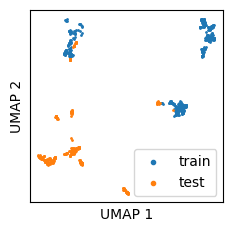

In [140]:
col = "aryl_c1_amide_c2_hetaryl_split"
sns.set_palette("tab10")

fig, ax = plt.subplots(1, 1, figsize=(2.5,2.5))

for series in ["train", "test"]:
    sub_emb = np.array([e for i,e in enumerate(embedding_pde) if df_pde_splits.loc[i, col] == series])
    
    ax.scatter(
        sub_emb[:, 0],
        sub_emb[:, 1],
        s=1, 
        label=series,
    )
    ax.legend(markerscale=3)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

fig.savefig(f"figs/umap_{col}.svg", bbox_inches="tight")

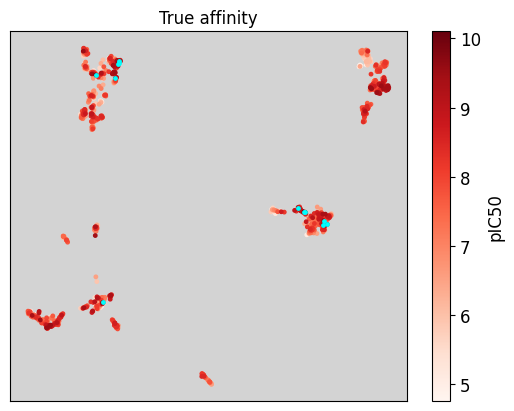

In [189]:
umap_plot(df_pde.pic50.tolist(), "pIC50", embedding_pde, title="True affinity")

top12 = df_pde.sort_values(by="pic50", ascending=False)[:12]

plt.scatter(
    embedding_pde[top12.index, 0],
    embedding_pde[top12.index, 1],
    c="cyan",
    s=6,
)

#plt.savefig("figs/umap_pde_pic50.svg", bbox_inches="tight")

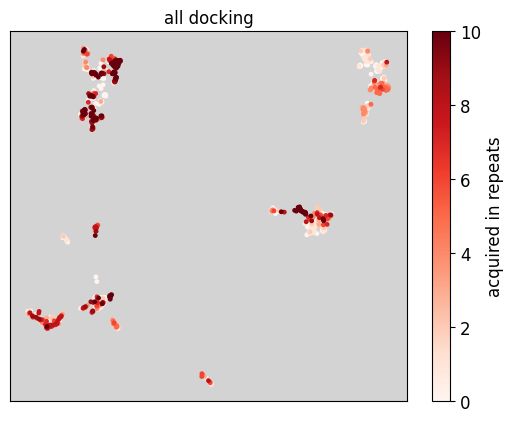

In [190]:
umap_plot(index_pde["20_all"], "acquired in repeats", embedding_pde, title="all docking")
#plt.savefig("figs/umap_pde_all.svg", bbox_inches="tight")

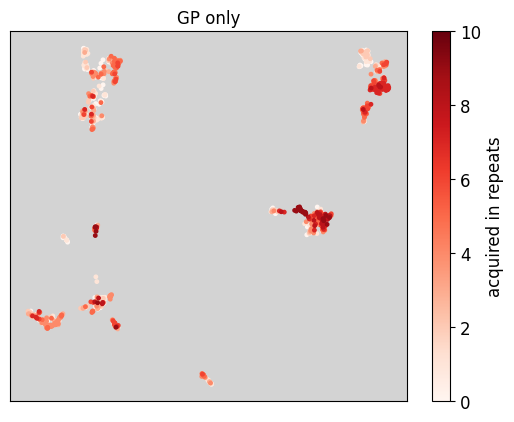

In [191]:
umap_plot(index_pde["20_gp"], "acquired in repeats", embedding_pde, title="GP only", normalize=True)
#plt.savefig("figs/umap_pde_gp.svg", bbox_inches="tight")

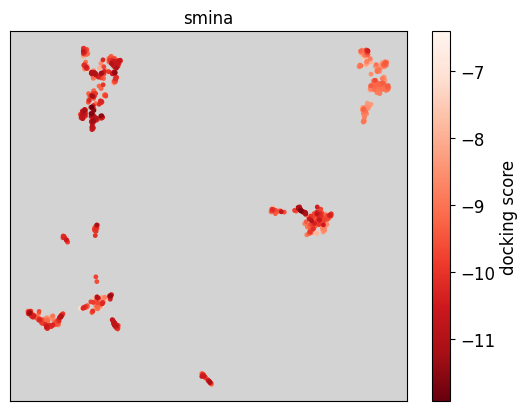

In [192]:
umap_plot(df_pde.smina.tolist(), "docking score", embedding_pde, title="smina", reverse=True)
#plt.savefig("figs/umap_pde_smina.svg", bbox_inches="tight")

In [282]:
import umap
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

reducer = umap.UMAP(n_neighbors=50, random_state=0)
embedding2 = reducer.fit_transform(df_tyk.fps.tolist())

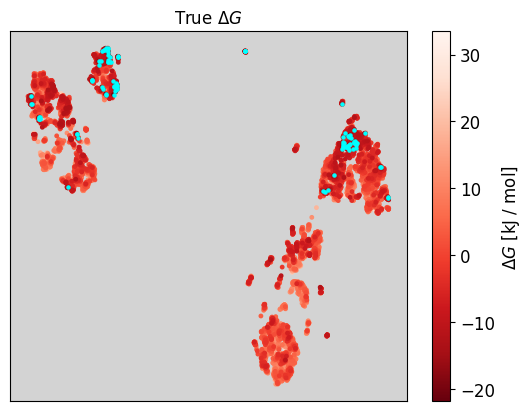

In [193]:
umap_plot(df_tyk.dG.tolist(), r'$\Delta G$ [kJ / mol]', embedding_tyk, title=r'True $\Delta G$', reverse=True)

top100 = df_tyk.sort_values(by="dG", ascending=True)[:100]

plt.scatter(
    embedding_tyk[top100.index, 0],
    embedding_tyk[top100.index, 1],
    c="cyan",
    s=5,
)
#plt.savefig("figs/umap_tyk2_pic50.svg", bbox_inches="tight")

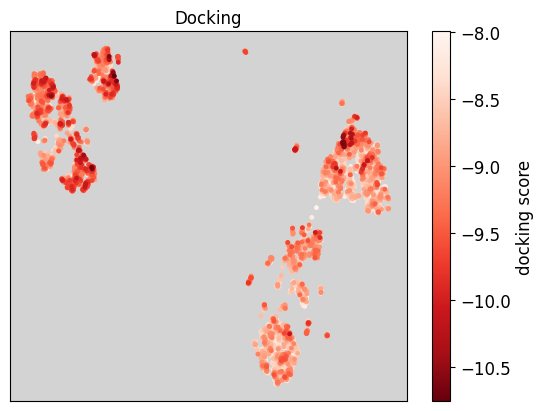

In [194]:
umap_plot(df_tyk.DockingScore.tolist(), "docking score", embedding_tyk, title="Docking", reverse=True)
#plt.savefig("figs/umap_tyk2_dock.svg", bbox_inches="tight")

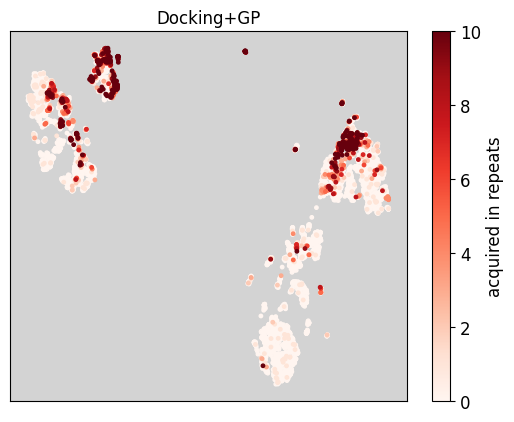

In [195]:
umap_plot(index_tyk["20_all"], "acquired in repeats", embedding_tyk, title="Docking+GP")
#plt.savefig("figs/umap_tyk2_all.svg", bbox_inches="tight")

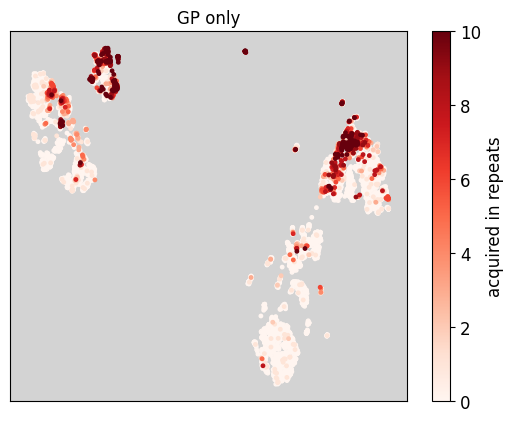

In [196]:
umap_plot(index_tyk["20_gp"], "acquired in repeats", embedding_tyk, title="GP only")
#plt.savefig("figs/umap_tyk2_gp.svg", bbox_inches="tight")

### pIC50 histogram of PDE10A scaffold splits

<Axes: xlabel='pic50', ylabel='Density'>

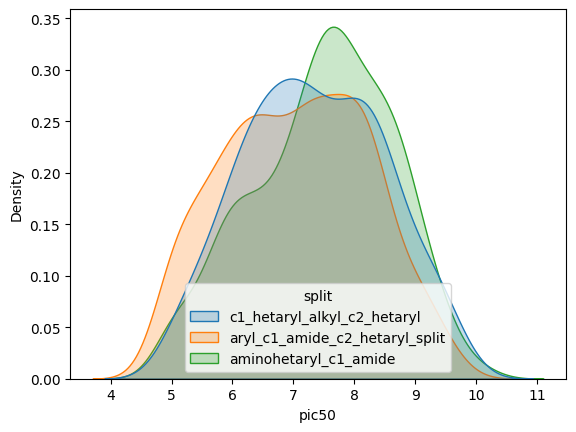

In [38]:
import seaborn as sns

def get_split(row):
    if row.c1_hetaryl_alkyl_c2_hetaryl_split == "test":
        return "c1_hetaryl_alkyl_c2_hetaryl"
    elif row.aminohetaryl_c1_amide_split == "test":
        return "aminohetaryl_c1_amide"
    elif row.aryl_c1_amide_c2_hetaryl_split == "test":
        return "aryl_c1_amide_c2_hetaryl_split"
    else:
        return None

df_plot = df_pde_splits.copy()
df_plot["split"] = df_plot.apply(get_split, axis=1)

sns.kdeplot(df_plot, x="pic50", hue="split", common_norm=False, fill=True, palette="tab10")
#plt.savefig("figs/pde10a-pic50-distribution.pdf", bbox_inches="tight")